# Deep Q-Network (DQN) for Turbofan Predictive Maintenance

## Approach

Offline RL framing — same as `02_q_learning.ipynb` but with a continuous state space.

| RL concept | Turbofan mapping |
|-----------|------------------|
| State `s` | 14-dim normalised rolling-average sensor vector |
| Action `a` | 0 = *continue*, 1 = *flag for maintenance* |
| Reward `r` | Asymmetric: missing a near-failure costs −10, false alarm −3 |
| Episode | One engine's life from cycle 1 → failure |
| Offline | Static CMAPSS log; no simulator interaction |

### Key fixes vs naive first version
- Buffer built **per episode** with a fresh 0-based index — no cross-unit row leakage
- **Balanced sampling** via `WeightedRandomSampler` — ~75 % of cycles are "continue", which collapses a naive model
- **Double DQN** target to reduce Q-value over-estimation bias
- Evaluation uses majority-vote over the last `VOTE_WINDOW` cycles (not just the final step)

In [ ]:
%pip install torch

  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 40.0 MB/s  0:00:12m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 36.4 MB/s  0:00:12m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 35.6 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 42.3 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 43.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 45.5 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 41.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 35.3 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

sns.set_theme(style='darkgrid')
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

DATA_DIR = Path('../data/CMaps')

INDEX_COLS   = ['unit', 'cycle']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_COLS  = [f's_{i}' for i in range(1, 22)]
ALL_COLS     = INDEX_COLS + SETTING_COLS + SENSOR_COLS
DEAD_SENSORS = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
LIVE_SENSORS = [s for s in SENSOR_COLS if s not in DEAD_SENSORS]
STATE_DIM    = len(LIVE_SENSORS)
N_ACTIONS    = 2
RUL_CAP      = 125
W            = 30
FLAG_THRESHOLD = 30
VOTE_WINDOW    = 15   # majority-vote over last K cycles at evaluation

# DQN hyper-parameters
LR            = 3e-4
GAMMA         = 0.97
BATCH_SIZE    = 512
N_EPOCHS      = 60
TARGET_UPDATE = 5
HIDDEN        = [256, 128, 64]

print(f'State dim: {STATE_DIM}')

Device: cpu
State dim: 14


## 1. Data Helpers

In [2]:
def load_train(fd_id: int) -> pd.DataFrame:
    df = pd.read_csv(DATA_DIR / f'train_FD00{fd_id}.txt',
                     sep=r'\s+', header=None, names=ALL_COLS, index_col=False)
    max_cycle = df.groupby('unit')['cycle'].max().rename('max_cycle')
    df = df.merge(max_cycle, on='unit')
    df['RUL'] = (df['max_cycle'] - df['cycle']).clip(upper=RUL_CAP).astype(float)
    df.drop(columns='max_cycle', inplace=True)
    return df


def load_test(fd_id: int) -> pd.DataFrame:
    test = pd.read_csv(DATA_DIR / f'test_FD00{fd_id}.txt',
                       sep=r'\s+', header=None, names=ALL_COLS, index_col=False)
    rul_gt = pd.read_csv(DATA_DIR / f'RUL_FD00{fd_id}.txt',
                         sep=r'\s+', header=None, names=['RUL_end'], index_col=False)
    last_cycles = test.groupby('unit')['cycle'].max().rename('last_cycle')
    test = test.merge(last_cycles, on='unit')
    test['is_last'] = test['cycle'] == test['last_cycle']
    unit_ids = sorted(test['unit'].unique())
    rul_map  = dict(zip(unit_ids, rul_gt['RUL_end'].values))
    # RUL at any cycle = RUL_end + (last_cycle - current_cycle)
    test['true_RUL'] = test.apply(
        lambda r: float(rul_map[r['unit']] + (r['last_cycle'] - r['cycle'])), axis=1
    ).clip(upper=RUL_CAP)
    return test


def preprocess(df: pd.DataFrame, scaler: MinMaxScaler, fit: bool = False) -> pd.DataFrame:
    df = df.copy()
    for s in LIVE_SENSORS:
        df[s] = (df.groupby('unit')[s]
                   .transform(lambda x: x.rolling(W, min_periods=1).mean()))
    if fit:
        df[LIVE_SENSORS] = scaler.fit_transform(df[LIVE_SENSORS])
    else:
        df[LIVE_SENSORS] = scaler.transform(df[LIVE_SENSORS])
    return df


def reward_fn(action: int, rul: float) -> float:
    near = rul <= FLAG_THRESHOLD
    if action == 0 and not near: return  1.0
    if action == 0 and near:     return -10.0
    if action == 1 and not near: return -3.0
    return 5.0

## 2. Build Offline Replay Buffer with Balanced Sampling

**Class imbalance problem**: ~75 % of cycles have RUL > 30 (action=0).  
Without correction the model learns to always predict "continue" and scores 75 % accuracy —  
but misses every near-failure engine.  
Fix: `WeightedRandomSampler` so each mini-batch sees ~50 % flag / 50 % continue.

In [3]:
def build_buffer(train: pd.DataFrame):
    """
    Build (s, a, r, s', done) tensors.
    Reset index per episode so loc[i] and loc[i+1] are always consecutive
    within the same engine — no cross-unit row leakage.
    """
    S_list, A_list, R_list, SN_list, Done_list = [], [], [], [], []

    for _, episode in train.groupby('unit', sort=False):
        ep = episode[LIVE_SENSORS + ['RUL']].reset_index(drop=True)
        n  = len(ep)
        for i in range(n - 1):
            s_vec  = ep.loc[i,   LIVE_SENSORS].values.astype(np.float32)
            s_next = ep.loc[i+1, LIVE_SENSORS].values.astype(np.float32)
            rul_i  = float(ep.loc[i, 'RUL'])
            a      = int(rul_i <= FLAG_THRESHOLD)
            r      = reward_fn(a, rul_i)
            done   = (i == n - 2)
            S_list.append(s_vec);    A_list.append(a)
            R_list.append(r);        SN_list.append(s_next)
            Done_list.append(float(done))

    S    = torch.tensor(np.array(S_list),  dtype=torch.float32)
    A    = torch.tensor(A_list,            dtype=torch.long)
    R    = torch.tensor(R_list,            dtype=torch.float32)
    SN   = torch.tensor(np.array(SN_list), dtype=torch.float32)
    Done = torch.tensor(Done_list,         dtype=torch.float32)
    return S, A, R, SN, Done


def balanced_loader(S, A, R, SN, Done, batch_size=BATCH_SIZE):
    dataset = TensorDataset(S, A, R, SN, Done)
    counts  = np.bincount(A.numpy())
    weights = torch.tensor(1.0 / counts[A.numpy()], dtype=torch.double)
    sampler = WeightedRandomSampler(weights, num_samples=len(dataset), replacement=True)
    print(f'Buffer: {len(dataset):,} | '
          f'continue={counts[0]:,} ({100*counts[0]/len(dataset):.1f}%) '
          f'flag={counts[1]:,} ({100*counts[1]/len(dataset):.1f}%)')
    return DataLoader(dataset, batch_size=batch_size, sampler=sampler)


scaler = MinMaxScaler()
train  = preprocess(load_train(1), scaler, fit=True)
S, A, R, SN, Done = build_buffer(train)
loader = balanced_loader(S, A, R, SN, Done)

Buffer: 20,531 | continue=17,531 (85.4%) flag=3,000 (14.6%)


## 3. DQN Architecture (Deeper + BatchNorm + Dropout)

In [4]:
class DQN(nn.Module):
    def __init__(self, state_dim: int, n_actions: int, hidden: list):
        super().__init__()
        layers = [nn.BatchNorm1d(state_dim)]
        in_dim = state_dim
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(0.1)]
            in_dim  = h
        layers.append(nn.Linear(in_dim, n_actions))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


q_net    = DQN(STATE_DIM, N_ACTIONS, HIDDEN).to(DEVICE)
q_target = DQN(STATE_DIM, N_ACTIONS, HIDDEN).to(DEVICE)
q_target.load_state_dict(q_net.state_dict())
q_target.eval()

optimizer = optim.Adam(q_net.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
loss_fn   = nn.HuberLoss()   # less sensitive to large TD-error spikes than MSE

total_params = sum(p.numel() for p in q_net.parameters())
print(q_net)
print(f'\nParameters: {total_params:,}')

DQN(
  (net): Sequential(
    (0): BatchNorm1d(14, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Linear(in_features=14, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.1, inplace=False)
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.1, inplace=False)
    (10): Linear(in_features=64, out_features=2, bias=True)
  )
)

Parameters: 45,150


## 4. Training — Double DQN

Standard DQN over-estimates Q-values because the same network selects *and* evaluates actions.  
Double DQN fixes this: the **online network** selects the best next action,  
the **target network** evaluates it.

Epoch   1/60  loss=1.8328  lr=3.00e-04
Epoch  10/60  loss=0.2506  lr=2.80e-04
Epoch  20/60  loss=0.7292  lr=2.25e-04
Epoch  30/60  loss=1.2267  lr=1.50e-04
Epoch  40/60  loss=1.7275  lr=7.50e-05
Epoch  50/60  loss=2.2226  lr=2.01e-05
Epoch  60/60  loss=3.1301  lr=0.00e+00


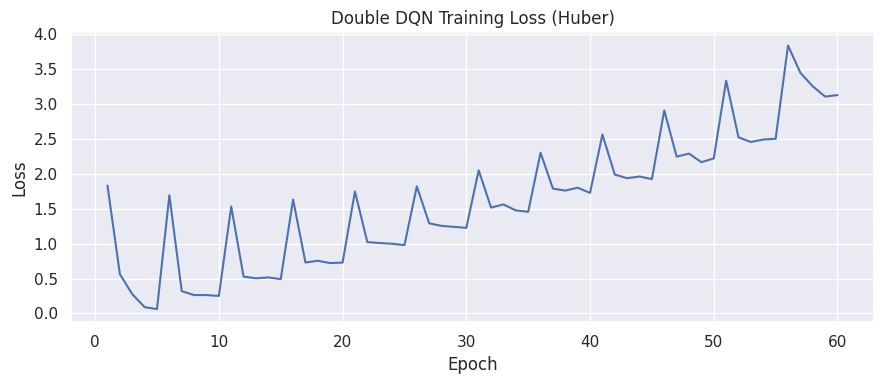

In [5]:
epoch_losses = []

for epoch in range(1, N_EPOCHS + 1):
    q_net.train()
    batch_losses = []

    for s_b, a_b, r_b, sn_b, done_b in loader:
        s_b, a_b, r_b = s_b.to(DEVICE), a_b.to(DEVICE), r_b.to(DEVICE)
        sn_b, done_b  = sn_b.to(DEVICE), done_b.to(DEVICE)

        # Current Q for taken actions
        q_vals = q_net(s_b).gather(1, a_b.unsqueeze(1)).squeeze(1)

        # Double DQN: online net selects action, target net evaluates it
        with torch.no_grad():
            best_a  = q_net(sn_b).argmax(dim=1, keepdim=True)
            q_next  = q_target(sn_b).gather(1, best_a).squeeze(1)
            targets = r_b + GAMMA * q_next * (1.0 - done_b)

        loss = loss_fn(q_vals, targets)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(q_net.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    scheduler.step()
    epoch_loss = np.mean(batch_losses)
    epoch_losses.append(epoch_loss)

    if epoch % TARGET_UPDATE == 0:
        q_target.load_state_dict(q_net.state_dict())
        q_target.eval()

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS}  loss={epoch_loss:.4f}  lr={scheduler.get_last_lr()[0]:.2e}')

plt.figure(figsize=(9, 4))
plt.plot(range(1, N_EPOCHS + 1), epoch_losses)
plt.title('Double DQN Training Loss (Huber)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.tight_layout(); plt.show()

## 5. Inspect Q-Values along a Degradation Trajectory

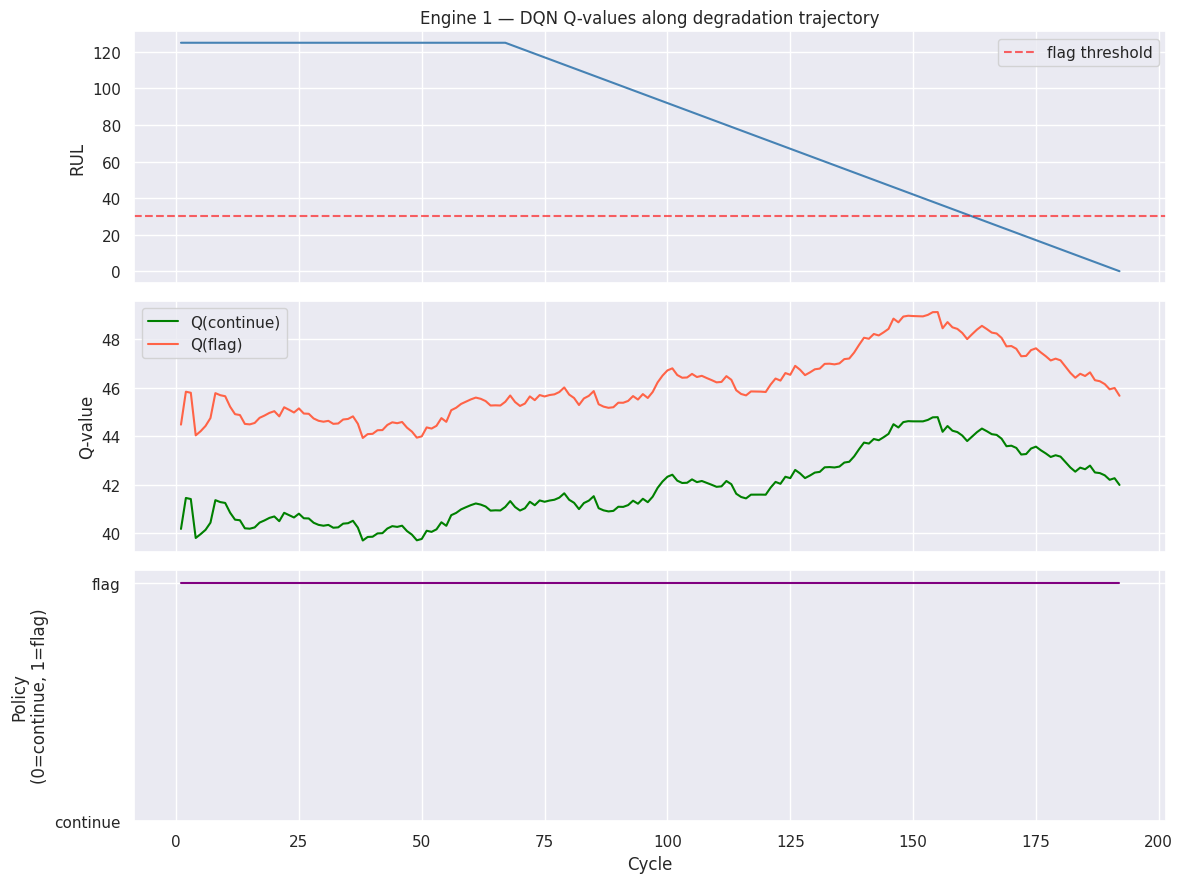

In [6]:
q_net.eval()

# Pick a representative engine from the training set
engine_id = 1
ep = train[train['unit'] == engine_id][LIVE_SENSORS + ['cycle', 'RUL']].reset_index(drop=True)
states_t = torch.tensor(ep[LIVE_SENSORS].values, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    q_vals_ep = q_net(states_t).cpu().numpy()  # shape (T, 2)

pred_actions = q_vals_ep.argmax(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
cycles = ep['cycle'].values

axes[0].plot(cycles, ep['RUL'].values, color='steelblue')
axes[0].axhline(FLAG_THRESHOLD, color='red', linestyle='--', alpha=0.6, label=f'flag threshold')
axes[0].set_ylabel('RUL')
axes[0].legend()
axes[0].set_title(f'Engine {engine_id} — DQN Q-values along degradation trajectory')

axes[1].plot(cycles, q_vals_ep[:, 0], label='Q(continue)', color='green')
axes[1].plot(cycles, q_vals_ep[:, 1], label='Q(flag)',     color='tomato')
axes[1].set_ylabel('Q-value')
axes[1].legend()

axes[2].step(cycles, pred_actions, color='purple', linewidth=1.5)
axes[2].set_ylabel('Policy\n(0=continue, 1=flag)')
axes[2].set_xlabel('Cycle')
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['continue', 'flag'])

plt.tight_layout()
plt.show()

## 6. Evaluation with Majority-Vote Window

Predicting from a single last cycle is noisy.  
We take **majority vote over the last `VOTE_WINDOW` cycles** per test unit — more robust.

FD001 | accuracy=0.250 | n_units=100
              precision    recall  f1-score   support

    continue       0.00      0.00      0.00        75
        flag       0.25      1.00      0.40        25

    accuracy                           0.25       100
   macro avg       0.12      0.50      0.20       100
weighted avg       0.06      0.25      0.10       100



/home/lux/luxchar/nasa-turbofan-offline-rl/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lux/luxchar/nasa-turbofan-offline-rl/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lux/luxchar/nasa-turbofan-offline-rl/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


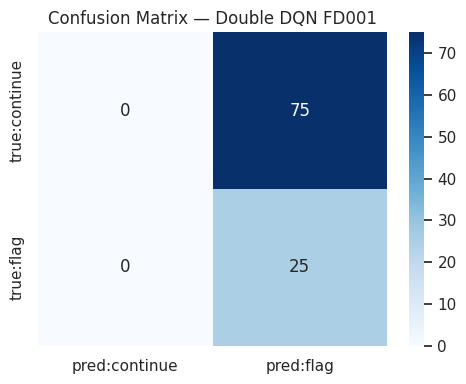

In [7]:
def evaluate_model(model, sc, fd_id, vote_window=VOTE_WINDOW, verbose=True):
    model.eval()
    test = preprocess(load_test(fd_id), sc, fit=False)
    states_t = torch.tensor(test[LIVE_SENSORS].values, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        test['pred_action'] = model(states_t).cpu().numpy().argmax(axis=1)

    results = []
    for uid, grp in test.groupby('unit'):
        vote     = int(grp.tail(vote_window)['pred_action'].mode()[0])
        true_rul = float(grp[grp['is_last']]['true_RUL'].iloc[0])
        true_act = int(true_rul <= FLAG_THRESHOLD)
        results.append({'unit': uid, 'pred': vote, 'true': true_act, 'true_RUL': true_rul})

    res_df = pd.DataFrame(results)
    acc = (res_df['pred'] == res_df['true']).mean()

    if verbose:
        print(f'FD00{fd_id} | accuracy={acc:.3f} | n_units={len(res_df)}')
        print(classification_report(res_df['true'], res_df['pred'],
                                     target_names=['continue', 'flag']))
        cm = confusion_matrix(res_df['true'], res_df['pred'])
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['pred:continue', 'pred:flag'],
                    yticklabels=['true:continue', 'true:flag'])
        ax.set_title(f'Confusion Matrix — Double DQN FD00{fd_id}')
        plt.tight_layout(); plt.show()

    return acc, res_df


acc_fd1, res_fd1 = evaluate_model(q_net, scaler, fd_id=1)

## 7. All-Dataset Benchmark (FD001–FD004)


=== FD001 ===
Buffer: 20,531 | continue=17,531 (85.4%) flag=3,000 (14.6%)
accuracy=0.250

=== FD002 ===
Buffer: 53,499 | continue=45,699 (85.4%) flag=7,800 (14.6%)
accuracy=0.236

=== FD003 ===
Buffer: 24,620 | continue=21,620 (87.8%) flag=3,000 (12.2%)
accuracy=0.200

=== FD004 ===
Buffer: 61,000 | continue=53,530 (87.8%) flag=7,470 (12.2%)
accuracy=0.214


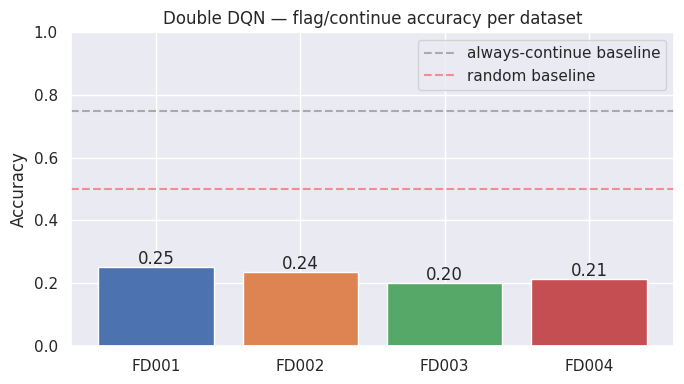

In [8]:
benchmark = []

for fd_id in range(1, 5):
    print(f'\n=== FD00{fd_id} ===')

    sc  = MinMaxScaler()
    tr  = preprocess(load_train(fd_id), sc, fit=True)
    S_, A_, R_, SN_, Done_ = build_buffer(tr)
    dl  = balanced_loader(S_, A_, R_, SN_, Done_)

    model  = DQN(STATE_DIM, N_ACTIONS, HIDDEN).to(DEVICE)
    tgt    = DQN(STATE_DIM, N_ACTIONS, HIDDEN).to(DEVICE)
    tgt.load_state_dict(model.state_dict()); tgt.eval()
    opt    = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS)
    hb     = nn.HuberLoss()

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        for sb, ab, rb, snb, db in dl:
            sb, ab, rb = sb.to(DEVICE), ab.to(DEVICE), rb.to(DEVICE)
            snb, db    = snb.to(DEVICE), db.to(DEVICE)
            qv  = model(sb).gather(1, ab.unsqueeze(1)).squeeze(1)
            with torch.no_grad():
                ba  = model(snb).argmax(1, keepdim=True)   # online selects
                nq  = tgt(snb).gather(1, ba).squeeze(1)    # target evaluates
                tv  = rb + GAMMA * nq * (1 - db)
            loss = hb(qv, tv)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sched.step()
        if epoch % TARGET_UPDATE == 0:
            tgt.load_state_dict(model.state_dict()); tgt.eval()

    acc, _ = evaluate_model(model, sc, fd_id, verbose=False)
    benchmark.append({'dataset': f'FD00{fd_id}', 'accuracy': acc})
    print(f'accuracy={acc:.3f}')

bdf = pd.DataFrame(benchmark)
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(bdf['dataset'], bdf['accuracy'], color=sns.color_palette()[:4])
ax.axhline(0.75, color='grey', linestyle='--', alpha=0.6, label='always-continue baseline')
ax.axhline(0.5,  color='red',  linestyle='--', alpha=0.4, label='random baseline')
ax.set_ylim(0, 1); ax.set_ylabel('Accuracy')
ax.set_title('Double DQN — flag/continue accuracy per dataset')
for bar, row in zip(bars, bdf.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{row.accuracy:.2f}', ha='center')
ax.legend()
plt.tight_layout(); plt.show()

## 8. Policy Roll-out Visualisation

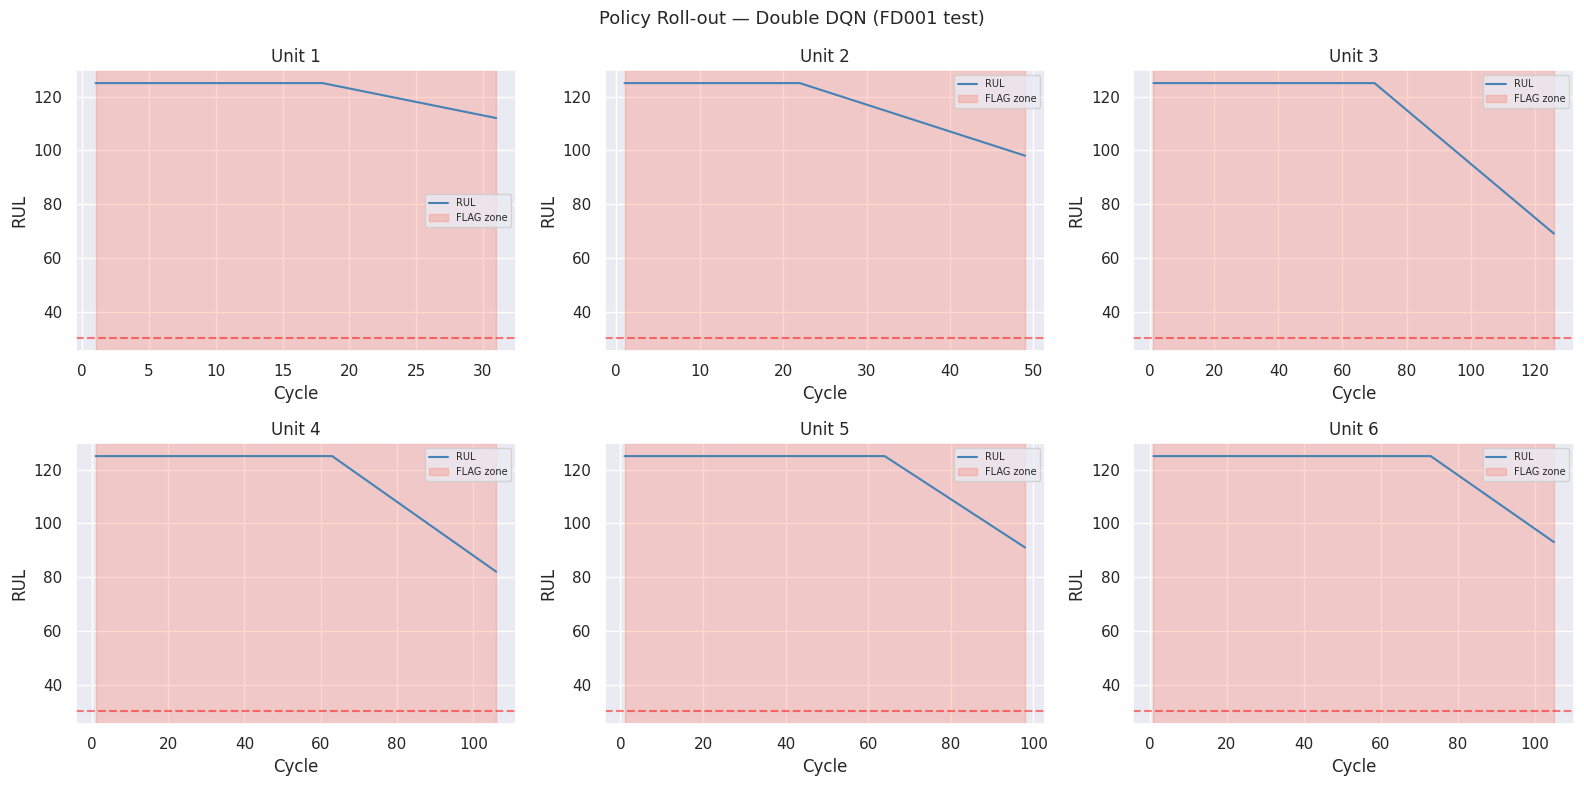

In [9]:
q_net.eval()
test_fd1 = preprocess(load_test(1), scaler, fit=False)
states_t  = torch.tensor(test_fd1[LIVE_SENSORS].values, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    test_fd1['pred_action'] = q_net(states_t).cpu().numpy().argmax(axis=1)

sample_units = test_fd1['unit'].unique()[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, uid in zip(axes.flat, sample_units):
    e = test_fd1[test_fd1['unit'] == uid].reset_index(drop=True)
    ax.plot(e['cycle'], e['true_RUL'], label='RUL', color='steelblue')
    flag_cycles = e[e['pred_action'] == 1]['cycle']
    if len(flag_cycles):
        ax.axvspan(flag_cycles.min(), flag_cycles.max(),
                   alpha=0.25, color='tomato', label='FLAG zone')
    ax.axhline(FLAG_THRESHOLD, color='red', linestyle='--', alpha=0.5)
    ax.set(title=f'Unit {uid}', xlabel='Cycle', ylabel='RUL')
    ax.legend(fontsize=7)
plt.suptitle('Policy Roll-out — Double DQN (FD001 test)', fontsize=13)
plt.tight_layout(); plt.show()

In [10]:
import os
os.makedirs('../models', exist_ok=True)
torch.save({
    'model_state':    q_net.state_dict(),
    'scaler':         scaler,
    'hidden':         HIDDEN,
    'state_dim':      STATE_DIM,
    'n_actions':      N_ACTIONS,
    'live_sensors':   LIVE_SENSORS,
    'rul_cap':        RUL_CAP,
    'flag_threshold': FLAG_THRESHOLD,
}, '../models/double_dqn_fd001.pt')
print('Saved → ../models/double_dqn_fd001.pt')

Saved → ../models/double_dqn_fd001.pt
